# B-8802B — AutoML: Melhor Modelo v4 (janelas 7/20 + sem rolling)

Analisa o **quick run** após corrigir a causa raiz dos falsos positivos.

**Causa raiz (confirmada por verificação adversarial):** com `normal_end_days=60` a janela
normal terminava em 07/mai — **antes** do início dos dados (15/mai) — ficando **vazia**.
Logo `normal_alert_rate=0` para todos os trials, a constraint `--max-fp-rate=1%` era
**silenciosamente desativada**, e o AutoML premiava o modelo mais "gatilho-fácil" (LOF),
que disparava por toda parte (FPs ~1 mês antes da falha).

**Correção v4:**
- `prefailure_days=7` (sinal real só na última semana) + `normal_end_days=20` (janela
  normal com ~5,2k amostras limpas → a constraint volta a morder)
- preset `rolling` removido (std/diff não ajudam em falha súbita e são os mais FP-prone)

- **Falha:** 06/Jul/2022 — Trinca nas lâminas do acoplamento
- **Task v4:** `c04149234c174e2fa90a0d2890af3393`

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from clearml import Task

PROJECT_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists()),
    Path.cwd(),
)
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from transpetro_modelos.config import EQUIPMENT_CONFIGS
from transpetro_modelos.data.loading import load_equipment_data
from transpetro_modelos.data.preprocessing import run_preprocessing
from transpetro_modelos.training.evaluate import failure_detection_metrics

In [2]:
# ==============================
# Configuracao
# ==============================
EQUIPMENT_ID = 'B-8802B'
TASK_V4 = 'c04149234c174e2fa90a0d2890af3393'  # IF baseline, janelas 7/20
TASK_V3 = '659b29a45d3c4b42977f438b08fc09fa'  # LOF rolling, janelas 30/60 (janela normal vazia)

# Janelas de avaliacao da v4 (devem casar com o run)
PREFAILURE_DAYS = 7
NORMAL_END_DAYS = 20

# Evento
EVENT_DATE_F1 = '2022-07-06 10:00'
EVENT_LABEL_F1 = 'Falha (06/Jul/2022)'
EVENT_TS_F1 = pd.Timestamp(EVENT_DATE_F1)

# Sensores-chave (modo de falha: trinca no acoplamento)
KEY_SENSORS = [
    'Vibração Bomba LNA',   # indicador líder (precursor ~01/jul)
    'Vibração Bomba LA',
    'Pressão Descarga',
    'Pressão Sucção',
    'Temperatura Bomba LA',
]

# Usa o threshold REAL do melhor trial do AutoML (fiel ao resultado 57.5%/0.97%).
# Mude para True para re-calibrar um threshold de exibição pela janela normal.
AUTO_USE_CALIBRATED_SENSITIVITY = False

FIGSIZE_WIDTH = 14
PANEL_HEIGHT = 2.4

# Plots separados (1 figura por sensor + 1 do score) salvos como PNG para slides
SAVE_PLOTS = True
OUTPUT_DPI = 200
OUTPUT_DIR = str(PROJECT_ROOT / 'notebooks' / 'b8802b' / 'plots')

In [3]:
def load_scores(task_id):
    """Carrega best_full_scores normalizado + task."""
    task = Task.get_task(task_id=task_id)
    s = task.artifacts['best_full_scores'].get()
    s.index = pd.to_datetime(s.index)
    s = s.sort_index()
    s['is_anomaly'] = s['is_anomaly'].astype(bool)
    return s[['reconstruction_error', 'is_anomaly']], task


def load_best_trial(task):
    bt = task.artifacts['best_trial'].get() if 'best_trial' in task.artifacts else None
    res = task.artifacts['automl_results'].get() if 'automl_results' in task.artifacts else None
    return bt, res


def persistence_filter(flags, k, n):
    if k == 1 and n == 1:
        return flags.astype(bool)
    roll = flags.astype(int).rolling(window=n, min_periods=n).sum()
    return (roll >= k).fillna(False).astype(bool)


def load_plot_base(equipment_id):
    config = EQUIPMENT_CONFIGS[equipment_id]
    df_raw = load_equipment_data(equipment_id, from_clearml=False)
    if config.pre_split_steps:
        df_base, _, _ = run_preprocessing(df_raw, config.pre_split_steps, fitted_scaler=None)
    else:
        df_base = df_raw
    df_base = df_base.sort_index()
    df_base.index = pd.to_datetime(df_base.index)
    return df_base, config

def _slug(text):
    return ''.join(ch if ch.isalnum() else '_' for ch in str(text)).strip('_').lower()

def plot_separated(df_window, scores_window, sensors, threshold, k, n, event_ts, event_label,
                   prefailure_days, title_prefix, tag, threshold_label='Limiar',
                   save=False, outdir=None, dpi=200):
    """Gera UMA figura por sensor + UMA do score (separadas, p/ slides). Salva PNG se save=True."""
    plt.style.use('seaborn-v0_8-whitegrid')
    flags = persistence_filter(scores_window['reconstruction_error'] > threshold, k=k, n=n)
    anom_idx = scores_window.index[flags]
    if save and outdir:
        from pathlib import Path as _P
        _P(outdir).mkdir(parents=True, exist_ok=True)
    saved = []
    for col in sensors:
        if col not in df_window.columns:
            continue
        fig, ax = plt.subplots(figsize=(FIGSIZE_WIDTH, 3.2))
        ax.plot(df_window.index, df_window[col], color='steelblue', linewidth=1.0, alpha=0.85, label=col)
        av = df_window[col].reindex(anom_idx).dropna()
        if not av.empty:
            ax.scatter(av.index, av.values, s=28, color='red', zorder=4, label='Anomalia')
        ax.axvspan(event_ts - pd.Timedelta(days=prefailure_days), event_ts, color='orange', alpha=0.08)
        ax.axvline(event_ts, color='orange', linestyle='--', linewidth=1.4, label=event_label)
        ax.set_ylabel(col, fontsize=9); ax.set_xlabel('Tempo'); ax.tick_params(labelsize=8)
        ax.legend(loc='upper left', fontsize=8, frameon=True)
        ax.set_title(f'{title_prefix} | {col}', fontsize=12, fontweight='bold')
        fig.tight_layout()
        if save and outdir:
            p = f'{outdir}/{tag}_{_slug(col)}.png'; fig.savefig(p, dpi=dpi, bbox_inches='tight'); saved.append(p)
        plt.show()
    fig, ax = plt.subplots(figsize=(FIGSIZE_WIDTH, 3.2))
    y = scores_window['reconstruction_error']
    ax.plot(y.index, y, color='purple', linewidth=0.9, alpha=0.6, label='Score de Anomalia')
    ax.axhline(threshold, color='red', linestyle='--', linewidth=1.2, label=threshold_label)
    if len(anom_idx):
        ax.scatter(anom_idx, y.reindex(anom_idx), s=28, color='red', zorder=4, label='Alerta')
    ax.axvspan(event_ts - pd.Timedelta(days=prefailure_days), event_ts, color='orange', alpha=0.08)
    ax.axvline(event_ts, color='orange', linestyle='--', linewidth=1.4, label=event_label)
    ax.set_ylabel('Score'); ax.set_xlabel('Tempo'); ax.tick_params(labelsize=8)
    ax.legend(loc='upper left', fontsize=8, frameon=True)
    ax.set_title(f'{title_prefix} | Score de Anomalia', fontsize=12, fontweight='bold')
    fig.tight_layout()
    if save and outdir:
        p = f'{outdir}/{tag}_score.png'; fig.savefig(p, dpi=dpi, bbox_inches='tight'); saved.append(p)
    plt.show()
    return saved

In [4]:
# ==============================
# Carrega v4 + melhor trial
# ==============================
scores, task4 = load_scores(TASK_V4)
bt4, res4 = load_best_trial(task4)
df_base, config = load_plot_base(EQUIPMENT_ID)

trial4 = bt4['trial']
results4 = bt4['results']
threshold4 = float(results4.get('threshold'))

print(f'Task v4: {task4.name}')
print(f'Scores: {len(scores)} amostras ({scores.index.min()} -> {scores.index.max()})')
print()
print('=== MELHOR TRIAL (v4) ===')
print(f"  Modelo:      {str(trial4.get('model')).upper()}")
print(f"  Preset:      {trial4.get('preset')}")
print(f"  Threshold:   p{trial4.get('threshold_percentile')}  (valor={threshold4:.4f})")
print(f"  Debounce:    {trial4.get('debounce_consecutive')} pts ({int(trial4.get('debounce_consecutive') or 1)*5} min)")
print(f"  prefailure:  {results4.get('prefailure_alert_rate'):.2%}")
print(f"  normal (FP): {results4.get('normal_alert_rate'):.2%}")
print(f"  composite:   {results4.get('composite_score'):.4f}")

Task v4: automl-b8802b-v4-win7-norm20-quick
Scores: 10792 amostras (2022-05-15 18:25:00 -> 2022-07-21 08:55:00)

=== MELHOR TRIAL (v4) ===
  Modelo:      ISOLATION_FOREST
  Preset:      baseline
  Threshold:   p99.0  (valor=0.5931)
  Debounce:    1 pts (5 min)
  prefailure:  57.52%
  normal (FP): 0.97%
  composite:   0.5696


In [5]:
# Ranking completo da v4 (so trials VIAVEIS sob a constraint de 1% aparecem)
cols = ['model', 'preset', 'threshold_percentile', 'debounce_consecutive',
        'prefailure_alert_rate', 'normal_alert_rate', 'composite_score',
        'n_normal_samples', 'n_prefailure_samples']
cols = [c for c in cols if c in res4.columns]
fmt = {'prefailure_alert_rate': '{:.2%}', 'normal_alert_rate': '{:.2%}',
       'composite_score': '{:.4f}', 'threshold_percentile': '{:.1f}'}
print(f'Trials viaveis (normal_alert_rate <= 1%): {len(res4)} de 8 testados')
display(res4[cols].style.format({k: v for k, v in fmt.items() if k in cols})
        .background_gradient(subset=['prefailure_alert_rate'], cmap='Greens')
        .background_gradient(subset=['normal_alert_rate'], cmap='Reds_r'))

Trials viaveis (normal_alert_rate <= 1%): 2 de 8 testados


,model,preset,threshold_percentile,debounce_consecutive,prefailure_alert_rate,normal_alert_rate,composite_score,n_normal_samples,n_prefailure_samples
0,isolation_forest,baseline,99.0,1,57.52%,0.97%,0.5696,5243,1071
1,lof,baseline,99.0,1,56.77%,0.97%,0.5622,5243,1071


## Comparação v3 → v4 (mesmas janelas 7/20)

Reavalia os scores das DUAS rodadas nas **mesmas janelas honestas (prefailure=7, normal_end=20)**,
usando o `is_anomaly` que cada uma já gravou no seu próprio threshold. Isso revela a taxa **real**
de falso positivo do v3 (cujo "0%" reportado era artefato da janela normal vazia).

In [6]:
# Reavalia v3 e v4 nas MESMAS janelas 7/20
scores_v3, task3 = load_scores(TASK_V3)
_, res3 = load_best_trial(task3)

def reeval(s, label, as_reported_normal=None):
    m = failure_detection_metrics(s, EVENT_TS_F1, prefailure_days=PREFAILURE_DAYS,
                                  normal_end_days=NORMAL_END_DAYS, consecutive=1)
    return {
        'rodada': label,
        'normal_REPORTADO': as_reported_normal,
        'normal_REAL@7/20': m['normal_alert_rate'],
        'prefailure@7/20': m['prefailure_alert_rate'],
        'composite@7/20': m['composite_score'],
        'n_normal': m['n_normal_samples'],
    }

norm_rep_v3 = float(res3.iloc[0]['normal_alert_rate']) if res3 is not None and len(res3) else None
norm_rep_v4 = float(res4.iloc[0]['normal_alert_rate']) if res4 is not None and len(res4) else None

comp = pd.DataFrame([
    reeval(scores_v3, 'v3 — LOF rolling (win 30/60)', norm_rep_v3),
    reeval(scores, 'v4 — IF baseline (win 7/20) ← atual', norm_rep_v4),
])
display(comp.style.format({
    'normal_REPORTADO': '{:.2%}', 'normal_REAL@7/20': '{:.2%}',
    'prefailure@7/20': '{:.2%}', 'composite@7/20': '{:.4f}',
}).background_gradient(subset=['normal_REAL@7/20'], cmap='Reds_r')
  .background_gradient(subset=['prefailure@7/20'], cmap='Greens'))

print('Leitura: o v3 reportava normal=0% (janela vazia, FALSO). Medido nas janelas 7/20,')
print('o FP REAL do v3 e muito maior — sao os disparos espalhados no periodo normal.')

,rodada,normal_REPORTADO,normal_REAL@7/20,prefailure@7/20,composite@7/20,n_normal
0,v3 — LOF rolling (win 30/60),0.00%,12.73%,99.07%,0.8645,5208
1,v4 — IF baseline (win 7/20) ← atual,0.97%,0.97%,57.52%,0.5696,5243


Leitura: o v3 reportava normal=0% (janela vazia, FALSO). Medido nas janelas 7/20,
o FP REAL do v3 e muito maior — sao os disparos espalhados no periodo normal.


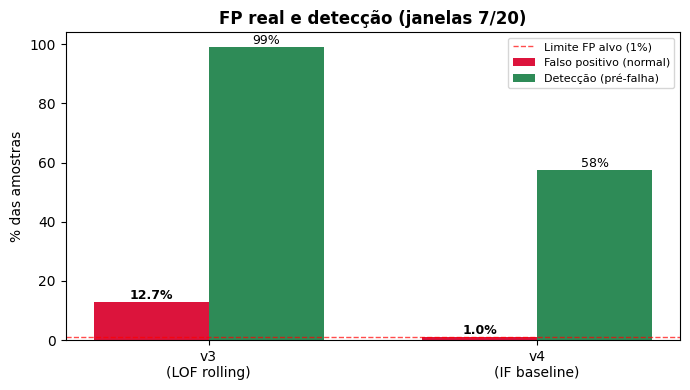

In [7]:
# Grafico de barras: FP real (normal) v3 vs v4
fig, ax = plt.subplots(figsize=(7, 4))
labels = ['v3\n(LOF rolling)', 'v4\n(IF baseline)']
fp = [comp.iloc[0]['normal_REAL@7/20'] * 100, comp.iloc[1]['normal_REAL@7/20'] * 100]
pre = [comp.iloc[0]['prefailure@7/20'] * 100, comp.iloc[1]['prefailure@7/20'] * 100]
x = np.arange(len(labels)); w = 0.35
ax.bar(x - w/2, fp, w, label='Falso positivo (normal)', color='crimson')
ax.bar(x + w/2, pre, w, label='Detecção (pré-falha)', color='seagreen')
ax.axhline(1.0, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Limite FP alvo (1%)')
for i, v in enumerate(fp):
    ax.text(i - w/2, v + 1, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
for i, v in enumerate(pre):
    ax.text(i + w/2, v + 1, f'{v:.0f}%', ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('% das amostras'); ax.set_title('FP real e detecção (janelas 7/20)', fontweight='bold')
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

In [8]:
# ==============================
# Threshold de exibicao
# ==============================
if AUTO_USE_CALIBRATED_SENSITIVITY:
    calib_end = EVENT_TS_F1 - pd.Timedelta(days=NORMAL_END_DAYS)
    calib = scores.loc[:calib_end, 'reconstruction_error']
    selected_threshold = float(np.percentile(calib.values, 99.0))
    threshold_label = f'Threshold calibrado (p99 janela normal = {selected_threshold:.4f})'
else:
    selected_threshold = threshold4
    threshold_label = f'Threshold do AutoML (p{trial4.get("threshold_percentile")} = {selected_threshold:.4f})'

selected_k = int(trial4.get('debounce_consecutive') or 1)
selected_n = selected_k
print(threshold_label)
print(f'Debounce: k={selected_k}, n={selected_n}')

Threshold do AutoML (p99.0 = 0.5931)
Debounce: k=1, n=1


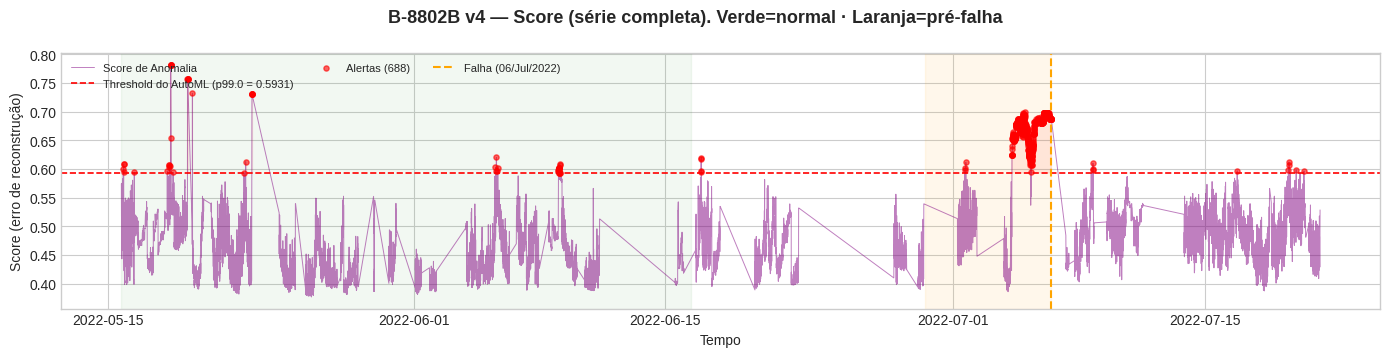

Total de alertas na série: 688


In [9]:
# ==============================
# Plot: serie completa (score + anomalias)
# ==============================
plt.style.use('seaborn-v0_8-whitegrid')
y = scores['reconstruction_error']
flags = persistence_filter(y > selected_threshold, k=selected_k, n=selected_n)

fig, ax = plt.subplots(figsize=(FIGSIZE_WIDTH, 3.6))
ax.plot(scores.index, y, color='purple', linewidth=0.7, alpha=0.5, label='Score de Anomalia')
ax.axhline(selected_threshold, color='red', linestyle='--', linewidth=1.2, label=threshold_label)
ax.fill_between(scores.index, selected_threshold, y, where=(y > selected_threshold),
                color='red', alpha=0.08)
idx = scores.index[flags]
ax.scatter(idx, y[idx], s=14, color='red', alpha=0.6, zorder=4, label=f'Alertas ({len(idx)})')
# Faixas de avaliacao
ax.axvspan(scores.index.min(), EVENT_TS_F1 - pd.Timedelta(days=NORMAL_END_DAYS),
           color='green', alpha=0.05)
ax.axvspan(EVENT_TS_F1 - pd.Timedelta(days=PREFAILURE_DAYS), EVENT_TS_F1,
           color='orange', alpha=0.08)
ax.axvline(EVENT_TS_F1, color='orange', linestyle='--', linewidth=1.5, label=EVENT_LABEL_F1)
ax.set_ylabel('Score (erro de reconstrução)'); ax.set_xlabel('Tempo')
ax.legend(loc='upper left', fontsize=8, ncol=3)
fig.suptitle(f'{EQUIPMENT_ID} v4 — Score (série completa). Verde=normal · Laranja=pré-falha',
             fontsize=13, fontweight='bold')
fig.tight_layout()
if SAVE_PLOTS:
    from pathlib import Path as _P; _P(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
    fig.savefig(f'{OUTPUT_DIR}/serie_completa_automl.png', dpi=OUTPUT_DPI, bbox_inches='tight')
plt.show()
print(f'Total de alertas na série: {int(flags.sum())}')

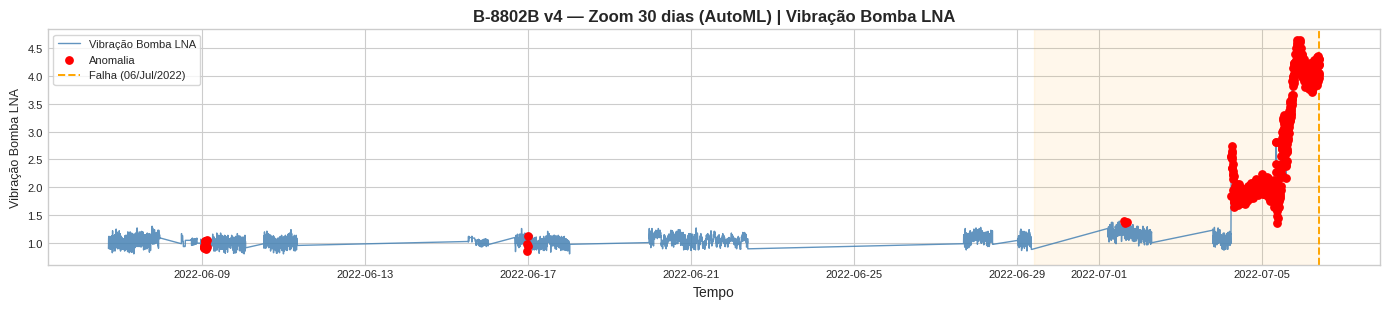

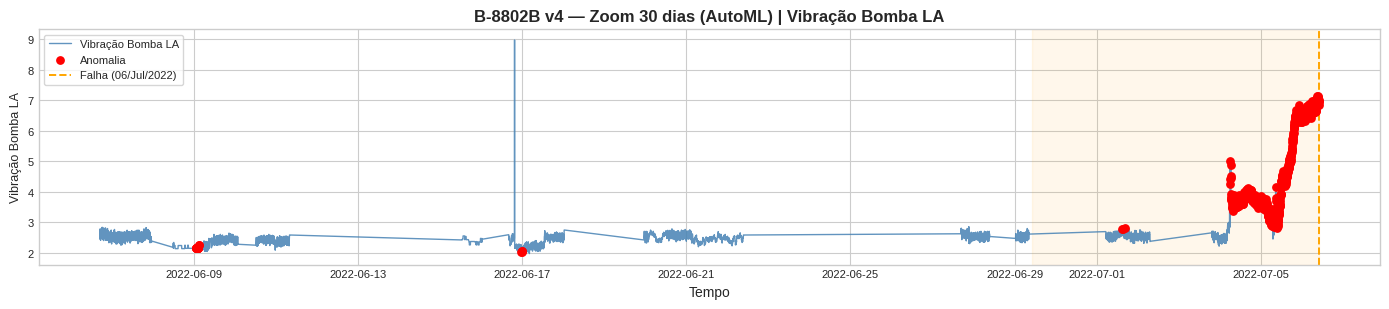

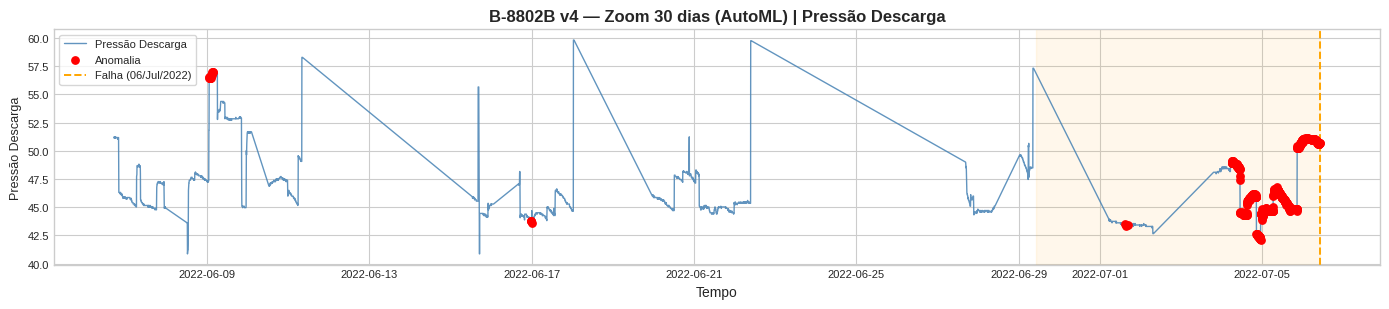

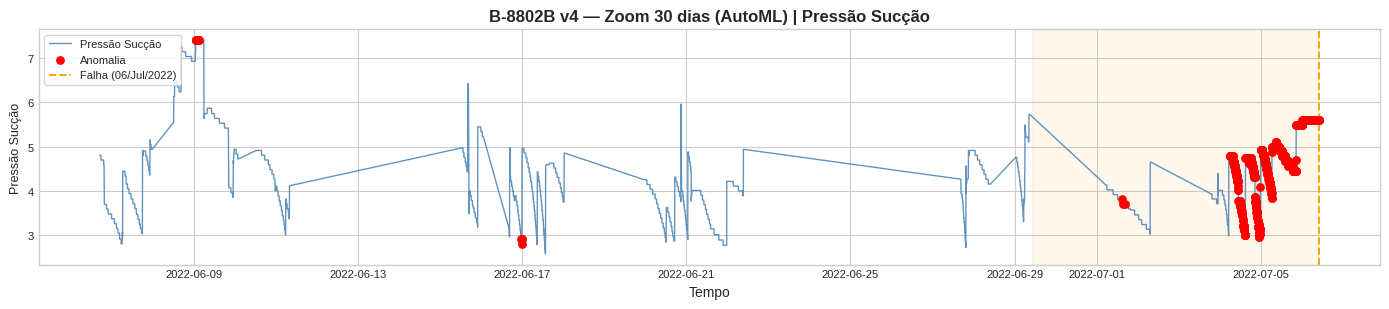

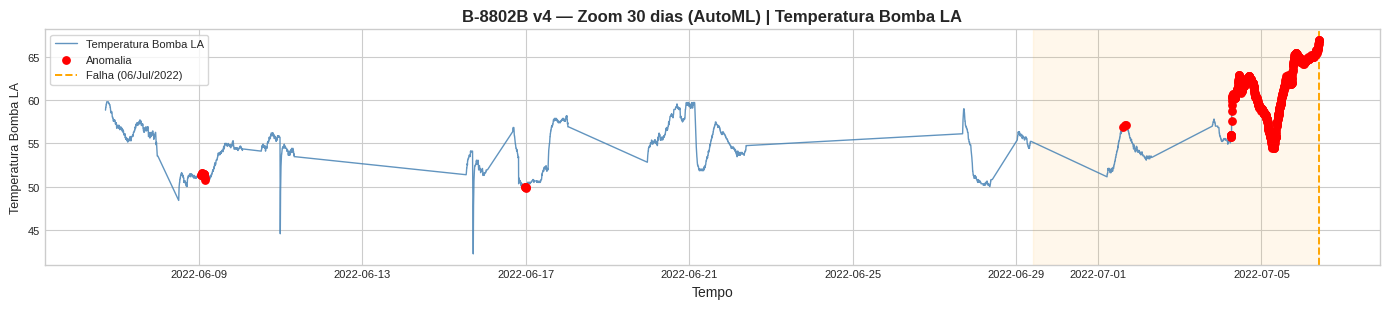

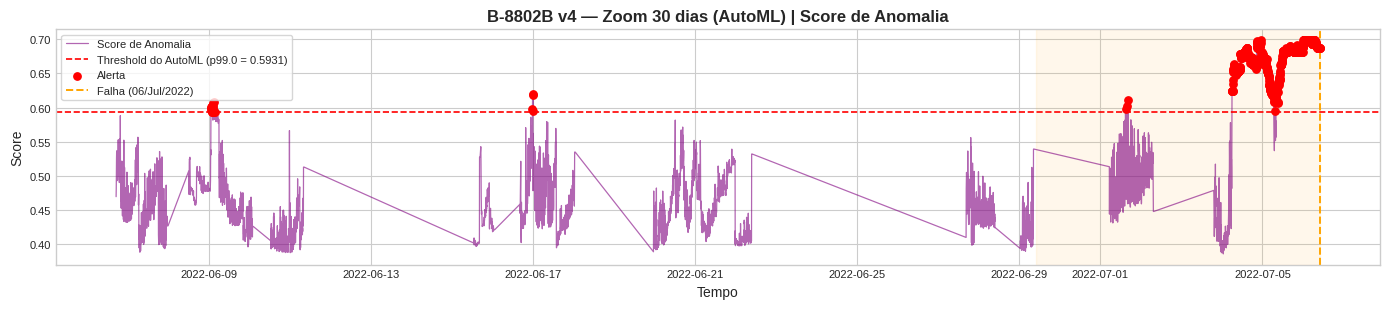

6 PNGs salvos em: /home/chico/Documentos/ciencia-dados/Transpetro-modelos/notebooks/b8802b/plots


In [10]:
# Zoom 30 dias — gráficos SEPARADOS (1 por sensor + 1 do score), AutoML threshold
zoom_start = EVENT_TS_F1 - pd.Timedelta(days=30)
dfw = df_base.loc[zoom_start:EVENT_TS_F1]
sw = scores.loc[zoom_start:EVENT_TS_F1]
common = dfw.index.intersection(sw.index)
dfw, sw = dfw.loc[common], sw.loc[common]
sensors = [s for s in KEY_SENSORS if s in dfw.columns]
saved = plot_separated(dfw, sw, sensors, selected_threshold, selected_k, selected_n,
                       EVENT_TS_F1, EVENT_LABEL_F1, PREFAILURE_DAYS,
                       title_prefix=f'{EQUIPMENT_ID} v4 — Zoom 30 dias (AutoML)',
                       tag='zoom30d_automl', threshold_label=threshold_label,
                       save=SAVE_PLOTS, outdir=OUTPUT_DIR, dpi=OUTPUT_DPI)
if SAVE_PLOTS:
    print(f'{len(saved)} PNGs salvos em: {OUTPUT_DIR}')

In [11]:
# ==============================
# Contagem de alertas por janela (7/20)
# ==============================
normal_end_ts = EVENT_TS_F1 - pd.Timedelta(days=NORMAL_END_DAYS)
pf_start_ts = EVENT_TS_F1 - pd.Timedelta(days=PREFAILURE_DAYS)
m_normal = scores.index < normal_end_ts
m_inter = (scores.index >= normal_end_ts) & (scores.index < pf_start_ts)
m_pre = (scores.index >= pf_start_ts) & (scores.index < EVENT_TS_F1)

print('=' * 70)
print(f'  CONTAGEM DE ALERTAS — {EQUIPMENT_ID} v4  (prefailure={PREFAILURE_DAYS}d, normal_end={NORMAL_END_DAYS}d)')
print('=' * 70)
print(f'  Threshold={selected_threshold:.4f}  debounce k={selected_k}/n={selected_n}')
print('-' * 70)
print(f'{"Janela":<34}{"Amostras":>10}{"Alertas":>10}{"Taxa":>10}')
print('-' * 70)
for name, mask in [(f'NORMAL (< -{NORMAL_END_DAYS}d)', m_normal),
                   (f'Buffer (-{NORMAL_END_DAYS}d a -{PREFAILURE_DAYS}d)', m_inter),
                   (f'PRÉ-FALHA (últimos {PREFAILURE_DAYS}d)', m_pre)]:
    n_s = int(mask.sum()); n_a = int(flags[mask].sum())
    rate = flags[mask].mean() if n_s else 0.0
    print(f'{name:<34}{n_s:>10,}{n_a:>10,}{rate:>9.2%}')
print('-' * 70)
print(f'{"TOTAL":<34}{len(flags):>10,}{int(flags.sum()):>10,}')
print('=' * 70)

  CONTAGEM DE ALERTAS — B-8802B v4  (prefailure=7d, normal_end=20d)
  Threshold=0.5931  debounce k=1/n=1
----------------------------------------------------------------------
Janela                              Amostras   Alertas      Taxa
----------------------------------------------------------------------
NORMAL (< -20d)                        5,243        51    0.97%
Buffer (-20d a -7d)                    1,406         4    0.28%
PRÉ-FALHA (últimos 7d)                 1,071       616   57.52%
----------------------------------------------------------------------
TOTAL                                 10,792       688


## Ajuste fino do limiar — sem retreinar

Os FPs isolados no período normal somem aumentando o **debounce** (exige N pontos consecutivos
acima do limiar): o sinal real de falha é sustentado por horas, os FPs são picos isolados.
O limiar é calibrado pelo **percentil da janela normal** (dados sabidamente limpos).

**Sobre os alertas após a falha (06/jul):** não são falsos positivos — são o **próprio evento**
(primeiros ~35 min, bomba ainda girando com o acoplamento trincado) + transiente do 1º reinício.
A série pós-falha tem 6 paradas/reinícios (equipamento em reparo).

In [12]:
# Grade de ajuste: percentil (janela normal) x debounce
def _deb(f, k, n):
    if k == 1 and n == 1:
        return f.astype(bool)
    return (f.astype(int).rolling(n, min_periods=n).sum() >= k).fillna(False).astype(bool)

_ne = EVENT_TS_F1 - pd.Timedelta(days=NORMAL_END_DAYS)
_ps = EVENT_TS_F1 - pd.Timedelta(days=PREFAILURE_DAYS)
_mn = scores.index < _ne
_mb = (scores.index >= _ne) & (scores.index < _ps)
_mp = (scores.index >= _ps) & (scores.index < EVENT_TS_F1)
_mpost = scores.index >= EVENT_TS_F1
_e = scores['reconstruction_error']

rows = []
for p in [99.0, 99.5, 99.7, 99.9]:
    thr = float(np.percentile(_e[_mn].values, p))
    for (k, n) in [(1, 1), (3, 5), (4, 6), (6, 8)]:
        fl = _deb(_e > thr, k, n)
        rows.append({'percentil': p, 'debounce': f'{k}/{n}', 'threshold': thr,
                     'normal_FP': fl[_mn].mean(), 'buffer': int(fl[_mb].sum()),
                     'prefalha': fl[_mp].mean(), 'pos_falha': int(fl[_mpost].sum())})
grid = pd.DataFrame(rows)
display(grid.style.format({'threshold': '{:.4f}', 'normal_FP': '{:.2%}', 'prefalha': '{:.1%}'})
        .background_gradient(subset=['normal_FP'], cmap='Reds_r')
        .background_gradient(subset=['prefalha'], cmap='Greens'))
print('Recomendado: percentil 99.5 + debounce 6/8 -> FP normal ~0.06%, detecção pré-falha ~56%.')
print('Para ZERO FP normal: p99.7 + 6/8 (custa metade da detecção pré-falha).')

,percentil,debounce,threshold,normal_FP,buffer,prefalha,pos_falha
0,99.000000,1/1,0.5924,1.01%,4,57.5%,20
1,99.000000,3/5,0.5924,0.76%,4,57.0%,13
2,99.000000,4/6,0.5924,0.53%,3,56.8%,10
3,99.000000,6/8,0.5924,0.23%,0,56.1%,10
4,99.500000,1/1,0.6030,0.51%,2,57.2%,11
5,99.500000,3/5,0.6030,0.36%,0,57.0%,10
6,99.500000,4/6,0.6030,0.25%,0,56.5%,10
7,99.500000,6/8,0.6030,0.06%,0,56.1%,10
8,99.700000,1/1,0.6748,0.31%,0,32.9%,8
9,99.700000,3/5,0.6748,0.29%,0,32.8%,10


Recomendado: percentil 99.5 + debounce 6/8 -> FP normal ~0.06%, detecção pré-falha ~56%.
Para ZERO FP normal: p99.7 + 6/8 (custa metade da detecção pré-falha).


In [13]:
# ==============================
# Aplica o limiar ajustado (mude à vontade)
# ==============================
TUNE_PERCENTILE = 99.5
TUNE_K, TUNE_N = 6, 8

selected_threshold = float(np.percentile(_e[_mn].values, TUNE_PERCENTILE))
selected_k, selected_n = TUNE_K, TUNE_N
threshold_label = f'Limiar ajustado (p{TUNE_PERCENTILE} normal = {selected_threshold:.4f}, debounce {TUNE_K}/{TUNE_N})'
flags = persistence_filter(scores['reconstruction_error'] > selected_threshold, k=selected_k, n=selected_n)

print(threshold_label)
print('-' * 58)
for nm, mk in [(f'NORMAL (< -{NORMAL_END_DAYS}d)', _mn), ('Buffer', _mb),
               (f'PRÉ-FALHA ({PREFAILURE_DAYS}d)', _mp), ('PÓS-FALHA', _mpost)]:
    print(f'{nm:<22}{int(flags[mk].sum()):>5} alertas  ({flags[mk].mean():>6.2%})')

post_idx = scores.index[_mpost & flags]
within2h = sum((t - EVENT_TS_F1) <= pd.Timedelta('2h') for t in post_idx)
print('-' * 58)
print(f'Pós-falha: {within2h} nos primeiros 2h (= evento) + {len(post_idx) - within2h} em reinício(s).')
print('-> Sem falso positivo real após a falha.')

Limiar ajustado (p99.5 normal = 0.6030, debounce 6/8)
----------------------------------------------------------
NORMAL (< -20d)           3 alertas  ( 0.06%)
Buffer                    0 alertas  ( 0.00%)
PRÉ-FALHA (7d)          601 alertas  (56.12%)
PÓS-FALHA                10 alertas  ( 0.33%)
----------------------------------------------------------
Pós-falha: 8 nos primeiros 2h (= evento) + 2 em reinício(s).
-> Sem falso positivo real após a falha.


## Zoom 14 dias antes da falha (limiar ajustado)

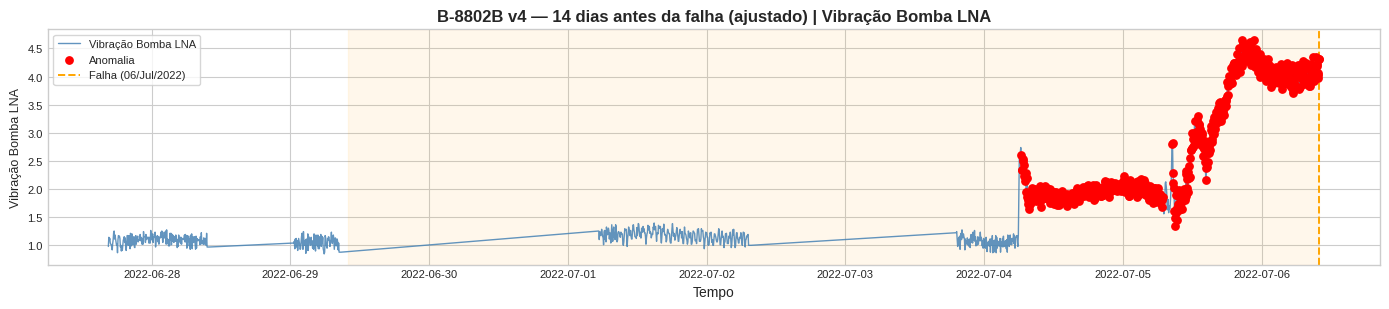

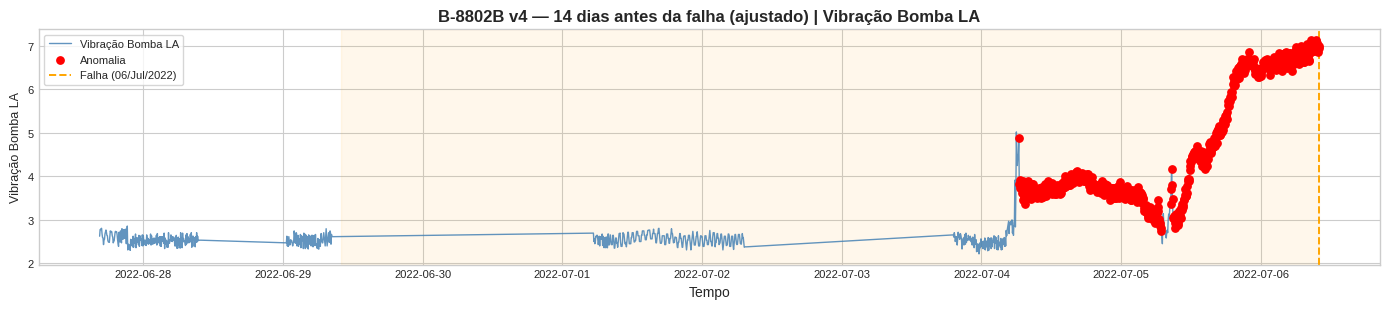

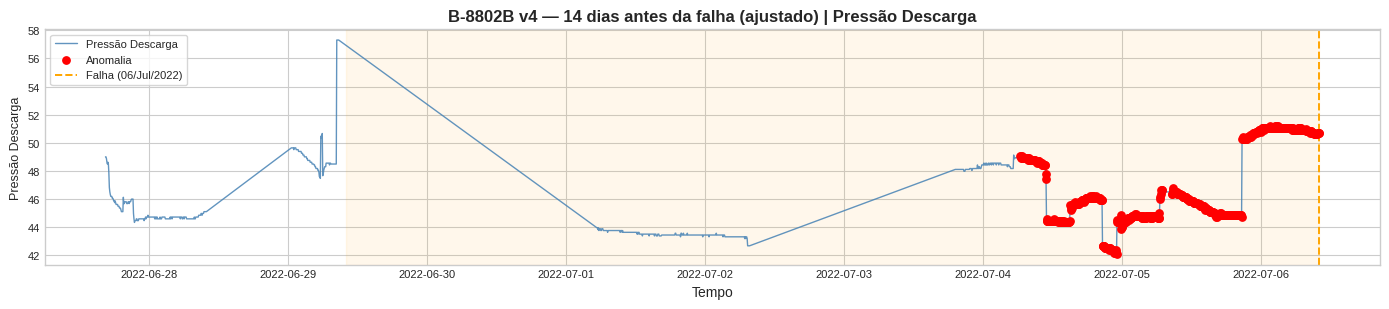

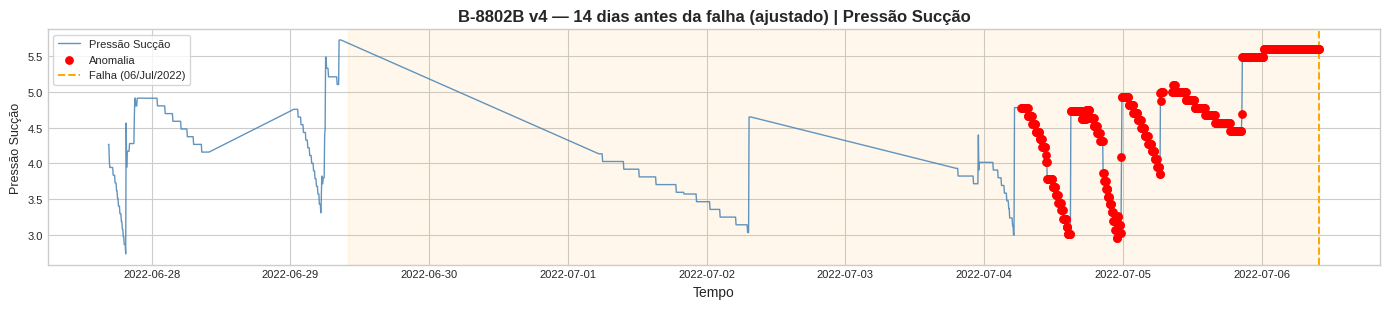

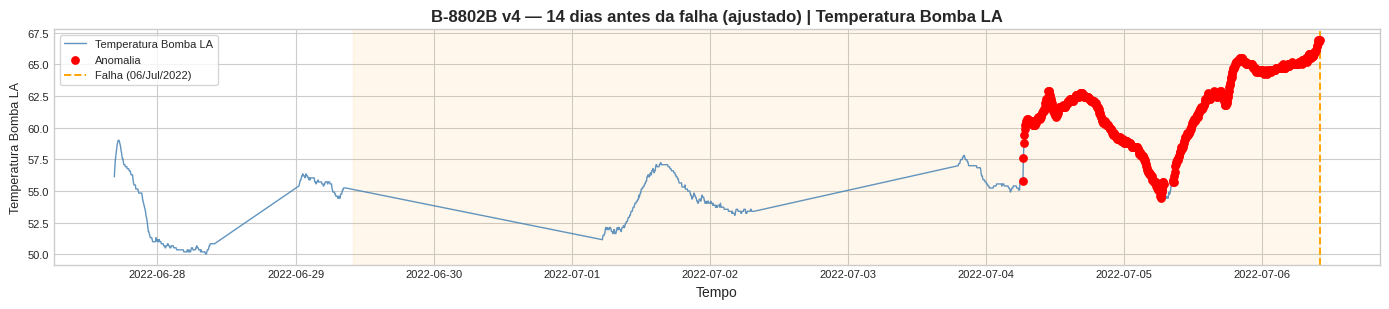

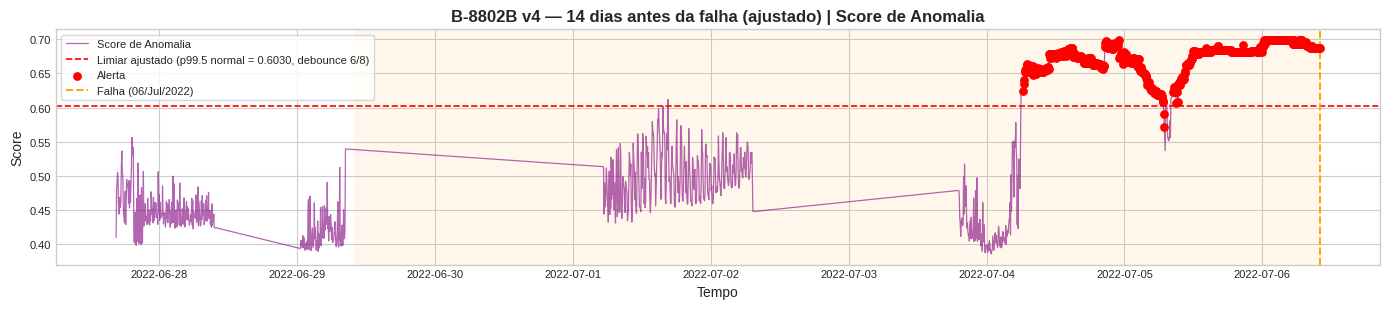

6 PNGs salvos em: /home/chico/Documentos/ciencia-dados/Transpetro-modelos/notebooks/b8802b/plots


In [14]:
# Zoom 14 dias — gráficos SEPARADOS (1 por sensor + 1 do score), limiar AJUSTADO
z = EVENT_TS_F1 - pd.Timedelta(days=14)
dfw = df_base.loc[z:EVENT_TS_F1]
sw = scores.loc[z:EVENT_TS_F1]
common = dfw.index.intersection(sw.index)
dfw, sw = dfw.loc[common], sw.loc[common]
sensors = [s for s in KEY_SENSORS if s in dfw.columns]
saved = plot_separated(dfw, sw, sensors, selected_threshold, selected_k, selected_n,
                       EVENT_TS_F1, EVENT_LABEL_F1, PREFAILURE_DAYS,
                       title_prefix=f'{EQUIPMENT_ID} v4 — 14 dias antes da falha (ajustado)',
                       tag='zoom14d_ajustado', threshold_label=threshold_label,
                       save=SAVE_PLOTS, outdir=OUTPUT_DIR, dpi=OUTPUT_DPI)
if SAVE_PLOTS:
    print(f'{len(saved)} PNGs salvos em: {OUTPUT_DIR}')

## Série completa com limiar ajustado

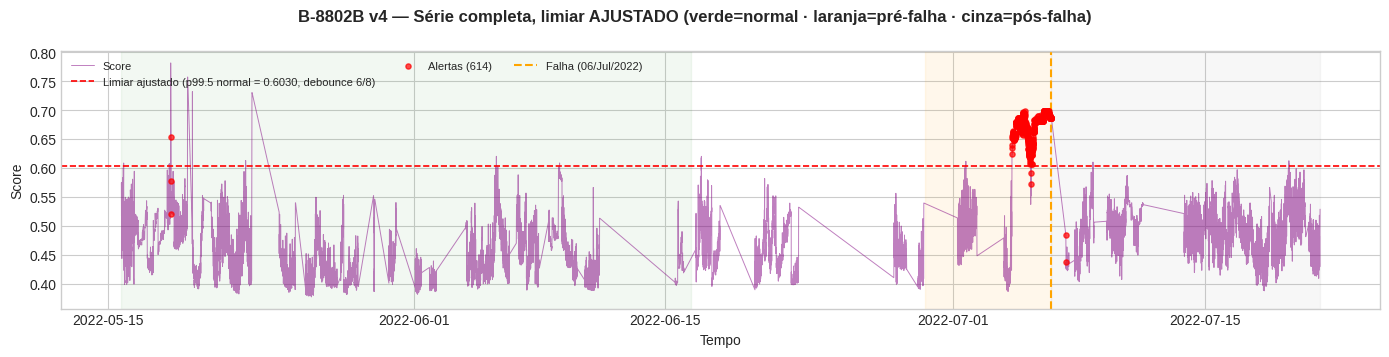

PNGs salvos em: /home/chico/Documentos/ciencia-dados/Transpetro-modelos/notebooks/b8802b/plots


In [15]:
plt.style.use('seaborn-v0_8-whitegrid')
y = scores['reconstruction_error']
fig, ax = plt.subplots(figsize=(FIGSIZE_WIDTH, 3.6))
ax.plot(scores.index, y, color='purple', linewidth=0.7, alpha=0.5, label='Score')
ax.axhline(selected_threshold, color='red', linestyle='--', linewidth=1.2, label=threshold_label)
idx = scores.index[flags]
ax.scatter(idx, y[idx], s=14, color='red', alpha=0.7, zorder=4, label=f'Alertas ({len(idx)})')
ax.axvspan(scores.index.min(), EVENT_TS_F1 - pd.Timedelta(days=NORMAL_END_DAYS), color='green', alpha=0.05)
ax.axvspan(EVENT_TS_F1 - pd.Timedelta(days=PREFAILURE_DAYS), EVENT_TS_F1, color='orange', alpha=0.08)
ax.axvspan(EVENT_TS_F1, scores.index.max(), color='gray', alpha=0.06)
ax.axvline(EVENT_TS_F1, color='orange', linestyle='--', linewidth=1.5, label=EVENT_LABEL_F1)
ax.set_ylabel('Score'); ax.set_xlabel('Tempo')
ax.legend(loc='upper left', fontsize=8, ncol=3)
fig.suptitle(f'{EQUIPMENT_ID} v4 — Série completa, limiar AJUSTADO (verde=normal · laranja=pré-falha · cinza=pós-falha)',
             fontsize=12, fontweight='bold')
fig.tight_layout()
if SAVE_PLOTS:
    from pathlib import Path as _P; _P(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
    fig.savefig(f'{OUTPUT_DIR}/serie_completa_ajustado.png', dpi=OUTPUT_DPI, bbox_inches='tight')
plt.show()
print(f'PNGs salvos em: {OUTPUT_DIR}')